# Federated Learning — FMI Temperature Prediction

**Task:** each FMI weather station is a node in an FL network.  
Every node trains a *local linear regression model* that predicts  
**tomorrow's daily maximum temperature** (tmax\_{t+1}) from today's [tmin\_t, tmax\_t].

**GTVMin objective** (from Lecture 2):

$$\min_{w^{(1)},\ldots,w^{(n)}\in\mathbb{R}^3} \sum_{i=1}^{n} \underbrace{\frac{1}{m_i}\|y^{(i)} - X^{(i)}w^{(i)}\|^2}_{L_i(w^{(i)})} + \alpha \sum_{\{i,j\}\in\mathcal{E}} A_{ij}\|w^{(i)}-w^{(j)}\|^2$$

| Step | What we do |
|------|-----------|
| **1. EDA** | Explore the raw FMI dataset |
| **2. Features** | Build per-station (X, y) arrays; chronological split; standardise |
| **3. Graphs** | System A — geographic k-NN;  System B — Pearson similarity |
| **4. Baseline** | Per-node OLS (α = 0, no collaboration) |
| **5. Tuning** | Grid-search α for each system using validation MSE |
| **6. Training** | FedGD and FedRelax with best hyperparameters |
| **7. Results** | Compare systems and interpret |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from functions import (
    load_data, get_station_meta, build_node_datasets,
    chronological_split, standardize_node_datasets,
    build_geo_graph, build_similarity_graph,
    graph_laplacian, graph_info, largest_connected_component,
    mse_loss, local_baseline,
    compute_safe_stepsize, run_fedgd, run_fedrelax,
    evaluate, tune_alpha, summary_table,
    plot_station_map, plot_graph, plot_loss_curves,
    plot_alpha_tuning, plot_per_station_mse,
)

np.random.seed(42)
DATA_PATH = "dataFLProject26/daily_records_base.csv"
print("Imports OK")

Imports OK


---
## Stage 1 — Exploratory Data Analysis

Raw data: `daily_records.csv` — 194 FMI stations across Finland, ~40 days of daily `tmin` / `tmax`.

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = load_data(DATA_PATH)

print(f"Shape            : {df.shape}")
print(f"Stations         : {df['station'].nunique()}")
print(f"Date range       : {df['day'].min().date()}  →  {df['day'].max().date()}")
print(f"Days covered     : {(df['day'].max() - df['day'].min()).days + 1}")
print(f"\nMissing values:")
print(df[["tmax", "tmin"]].isnull().sum().to_string())
print(f"\nSample rows:")
df.head()

Shape            : (7724, 6)
Stations         : 194
Date range       : 2026-01-22  →  2026-03-02
Days covered     : 40

Missing values:
tmax    0
tmin    0

Sample rows:


,station,lat,lon,day,tmax,tmin
0,Alajärvi Möksy,63.08898,24.26084,2026-01-22,-7.9,-11.1
1,Alajärvi Möksy,63.08898,24.26084,2026-01-23,-11.1,-13.0
2,Alajärvi Möksy,63.08898,24.26084,2026-01-24,-11.9,-14.2
3,Alajärvi Möksy,63.08898,24.26084,2026-01-25,-10.1,-19.1
4,Alajärvi Möksy,63.08898,24.26084,2026-01-26,-6.9,-10.9


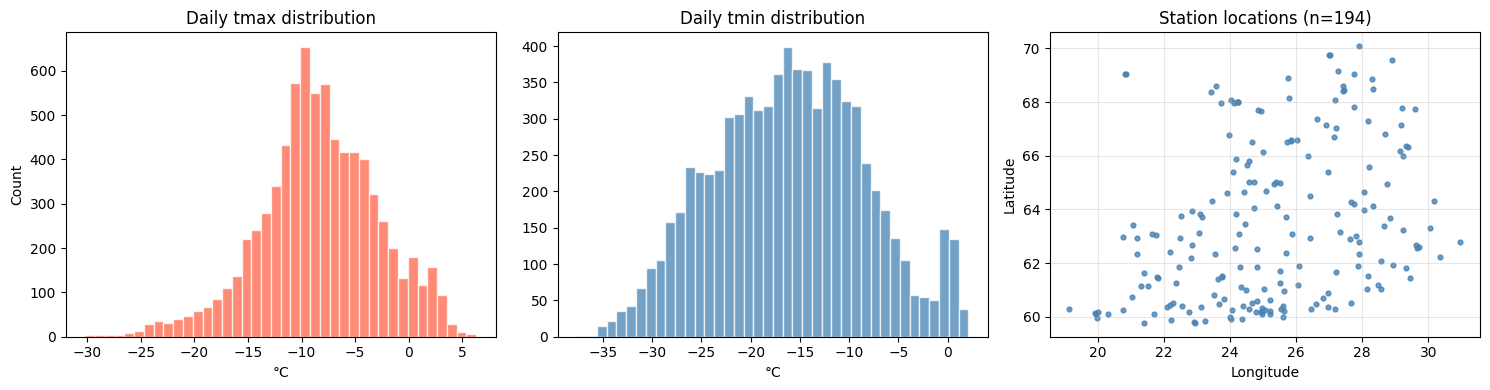

tmax range: -30.2 to 6.3 °C
tmin range: -37.6 to 2.1 °C


In [3]:
# ── Temperature distributions and geographic scatter ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of tmax
axes[0].hist(df["tmax"].dropna(), bins=40, color="tomato", alpha=0.75, edgecolor="white")
axes[0].set_title("Daily tmax distribution")
axes[0].set_xlabel("°C")
axes[0].set_ylabel("Count")

# Distribution of tmin
axes[1].hist(df["tmin"].dropna(), bins=40, color="steelblue", alpha=0.75, edgecolor="white")
axes[1].set_title("Daily tmin distribution")
axes[1].set_xlabel("°C")

# Geographic scatter of all stations
meta = get_station_meta(df)
axes[2].scatter(meta["lon"], meta["lat"], s=12, c="steelblue", alpha=0.8)
axes[2].set_title(f"Station locations (n={len(meta)})")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"tmax range: {df['tmax'].min():.1f} to {df['tmax'].max():.1f} °C")
print(f"tmin range: {df['tmin'].min():.1f} to {df['tmin'].max():.1f} °C")

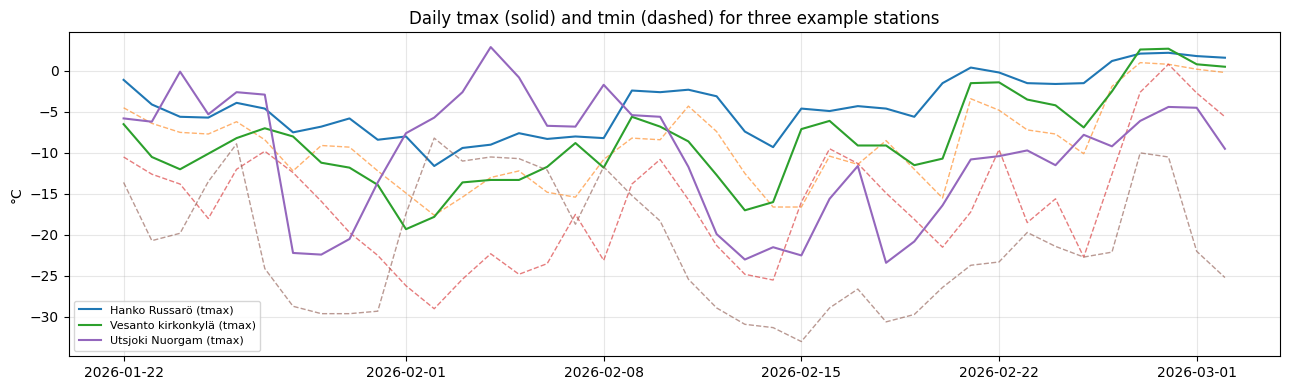

In [4]:
# ── Temperature time series: a few example stations ─────────────────────────
example_stations = ["Helsinki Kaisaniemi", "Sodankylä", "Rovaniemi lentoasema"]
example_stations = [s for s in example_stations if s in df["station"].values]

# Fallback: pick 3 stations spread from south to north
if len(example_stations) < 3:
    meta_sorted = get_station_meta(df).sort_values("lat")
    example_stations = [
        meta_sorted.iloc[0]["station"],
        meta_sorted.iloc[len(meta_sorted) // 2]["station"],
        meta_sorted.iloc[-1]["station"],
    ]

fig, ax = plt.subplots(figsize=(13, 4))
for sname in example_stations:
    sub = df[df["station"] == sname].sort_values("day")
    ax.plot(sub["day"], sub["tmax"], label=f"{sname} (tmax)", linewidth=1.5)
    ax.plot(sub["day"], sub["tmin"], linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Daily tmax (solid) and tmin (dashed) for three example stations")
ax.set_ylabel("°C")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Stage 2 — Feature Engineering

**Why linear regression?**  
Each node has roughly 23 training points and 3 features ([bias, tmin, tmax]).  
A linear model is:
- *Underpinned by physics*: tomorrow's max temperature correlates linearly with today's temps.
- *Safe from overfitting*: with m ≈ 23 << n = 3, a non-linear model would overfit hopelessly.
- *Analytically tractable*: the loss is convex and smooth → FedGD converges provably.
- *Efficient for FL*: the gradient is closed-form and FedRelax reduces to ridge regression.

**Feature vector:** $x^{(i,t)} = [1,\ \text{tmin}_t,\ \text{tmax}_t]^\top \in \mathbb{R}^3$  
**Label:** $y^{(i,t)} = \text{tmax}_{t+1}$  
**Chronological split:** first 60% → train, next 20% → val, last 20% → test  
(Random shuffling is *not* valid for time-series data.)

In [5]:
# ── Build per-station datasets ───────────────────────────────────────────────
NODE_DATASETS = build_node_datasets(df, min_points=30)
NODE_DATASETS = chronological_split(NODE_DATASETS, train_frac=0.60, val_frac=0.20)
NODE_DATASETS = standardize_node_datasets(NODE_DATASETS)

ALL_NAMES = sorted(NODE_DATASETS.keys())

print(f"Stations with ≥ 30 consecutive data points: {len(ALL_NAMES)}")

# Inspect one example station
ex_name = ALL_NAMES[0]
ex = NODE_DATASETS[ex_name]
print(f"\nExample station: '{ex_name}'")
print(f"  Total pairs     : {len(ex['y'])}")
print(f"  Train / Val / Test: {len(ex['train_idx'])} / {len(ex['val_idx'])} / {len(ex['test_idx'])}")
print(f"  X shape         : {ex['X_std'].shape}   (columns: bias, tmin_std, tmax_std)")
print(f"  y range         : [{ex['y'].min():.1f}, {ex['y'].max():.1f}] °C")

Stations with ≥ 30 consecutive data points: 193

Example station: 'Alajärvi Möksy'
  Total pairs     : 39
  Train / Val / Test: 23 / 7 / 9
  X shape         : (39, 3)   (columns: bias, tmin_std, tmax_std)
  y range         : [-20.3, 2.7] °C


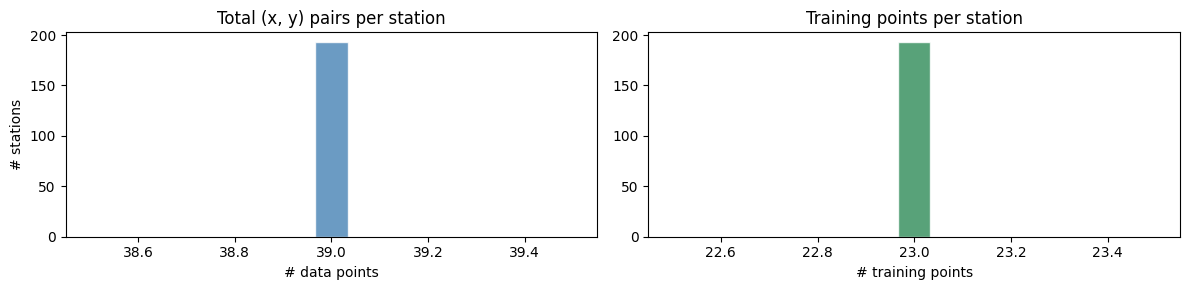

Median training size: 23 points — small, which motivates FL collaboration.


In [6]:
# ── Dataset size distribution ─────────────────────────────────────────────────
m_vals = [len(NODE_DATASETS[n]["y"]) for n in ALL_NAMES]
m_train = [len(NODE_DATASETS[n]["train_idx"]) for n in ALL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(m_vals, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Total (x, y) pairs per station")
axes[0].set_xlabel("# data points")
axes[0].set_ylabel("# stations")

axes[1].hist(m_train, bins=15, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title("Training points per station")
axes[1].set_xlabel("# training points")
plt.tight_layout()
plt.show()

print(f"Median training size: {np.median(m_train):.0f} points — small, which motivates FL collaboration.")

---
## Stage 3 — Graph Construction

We explore two structurally different ways to define the FL network.

### System A — Geographic k-NN graph

Connect each station to its **k geographically closest** neighbours (Haversine distance).  
Edge weight: $A_{ij} = \exp\!\left(-\dfrac{d_{ij}^2}{2\sigma^2}\right)$, $\sigma$ = median pairwise distance.

*Rationale:* physically close stations share similar microclimates; their models should be similar.

### System B — Data-similarity graph (Pearson correlation)

Connect stations $i$ and $j$ if their **Pearson correlation on training tmax** ≥ threshold.  
Edge weight: $A_{ij} = \text{corr}(y_{\text{train}}^{(i)},\, y_{\text{train}}^{(j)})$.

*Rationale:* stations with historically correlated temperatures are subject to the same synoptic weather patterns regardless of distance.  Similarity is computed on **training data only** to avoid leakage.

In [7]:
# ── System A: explore k ∈ {2, 3, 5, 8} ───────────────────────────────────────
stations_list = [NODE_DATASETS[n] for n in ALL_NAMES]

print("System A — Geographic k-NN graph  (exploring k):")
print(f"{'k':>4}  {'edges':>6}  {'components':>10}  {'connected':>9}  {'λ₂':>10}  {'mean_deg':>8}")
for k in [2, 3, 5, 8]:
    A_tmp = build_geo_graph(stations_list, k=k)
    info  = graph_info(A_tmp)
    print(f"{k:>4}  {info['n_edges']:>6}  {info['n_components']:>10}  "
          f"{str(info['is_connected']):>9}  {info['lambda_2']:>10.4f}  {info['degree_mean']:>8.2f}")

System A — Geographic k-NN graph  (exploring k):
   k   edges  components  connected          λ₂  mean_deg
   2     256           9      False     -0.0000      2.64
   3     375           3      False     -0.0000      3.86
   5     588           1       True      0.0201      6.03
   8     927           1       True      0.0608      9.46


In [8]:
# ── System A: select k=5 (minimum k giving full connectivity) ──────────────
# k=2 → 9 components (offshore islands isolated)
# k=3 → 3 components (still some disconnect)
# k=5 → 1 component  ← CHOSEN: minimum k that yields a connected graph
# k=8 → 1 component  (denser but not necessary)

K_GEO = 5
A_GEO_ALL = build_geo_graph(stations_list, k=K_GEO)
info_geo_all = graph_info(A_GEO_ALL)

print(f"System A (k={K_GEO}):")
for key, val in info_geo_all.items():
    print(f"  {key:15}: {val}")

System A (k=5):
  n_nodes        : 193
  n_edges        : 588
  density        : 0.0317
  degree_min     : 4.701146075006825
  degree_max     : 9.984888669660467
  degree_mean    : 6.031241541086759
  lambda_2       : 0.020138824247319533
  lambda_max     : 11.984489551971006
  n_components   : 1
  is_connected   : True


In [9]:
# ── System B: explore threshold ∈ {0.7, 0.8, 0.9} ──────────────────────────
print("System B — Pearson correlation graph  (exploring threshold):")
print(f"{'thr':>5}  {'edges':>6}  {'LCC size':>8}  {'connected':>9}  {'density':>8}")
for thr in [0.7, 0.8, 0.9]:
    A_tmp = build_similarity_graph(NODE_DATASETS, ALL_NAMES, threshold=thr)
    info  = graph_info(A_tmp)
    _, lcc = largest_connected_component(A_tmp, ALL_NAMES)
    print(f"{thr:>5.1f}  {info['n_edges']:>6}  {len(lcc):>8}  "
          f"{str(info['is_connected']):>9}  {info['density']:>8.4f}")

System B — Pearson correlation graph  (exploring threshold):
  thr   edges  LCC size  connected   density
  0.7    4938       192      False    0.2665
  0.8    2766       190      False    0.1493
  0.9     937       117      False    0.0506


In [10]:
# ── System B: select threshold = 0.8; restrict to LCC ───────────────────────
# thr=0.7 → LCC 192 nodes (good but we want sparser, more meaningful edges)
# thr=0.8 → LCC 190 nodes ← CHOSEN: reasonable sparsity; 3 offshore islands excluded
# thr=0.9 → LCC 117 nodes (too sparse; many disconnected cluster)
#
# The 3 stations outside the LCC have unusual temperature patterns
# (likely remote offshore islands) — excluding them is a valid design decision.

THR_SIM = 0.8
A_SIM_FULL = build_similarity_graph(NODE_DATASETS, ALL_NAMES, threshold=THR_SIM)
A_SIM_SUB, SIM_NAMES = largest_connected_component(A_SIM_FULL, ALL_NAMES)

info_sim = graph_info(A_SIM_SUB)
print(f"System B (threshold={THR_SIM}, LCC):")
for key, val in info_sim.items():
    print(f"  {key:15}: {val}")

print(f"\nExcluded stations: {set(ALL_NAMES) - set(SIM_NAMES)}")

System B (threshold=0.8, LCC):
  n_nodes        : 190
  n_edges        : 2766
  density        : 0.1541
  degree_min     : 0.857208964314142
  degree_max     : 68.0208762943426
  degree_mean    : 25.55853863922725
  lambda_2       : 0.08772594110943834
  lambda_max     : 69.07806780225431
  n_components   : 1
  is_connected   : True

Excluded stations: {'Puolanka Paljakka', 'Kuusamo Rukatunturi', 'Hammarland Märket'}


In [11]:
# ── Align both systems to the same 190-station node set ──────────────────────
# For a fair experiment, both systems must operate on the same set of nodes.
# We use the LCC of System B (190 stations) for both.

SHARED_NAMES = SIM_NAMES                             # 190 stations, sorted
shared_idx   = [ALL_NAMES.index(n) for n in SHARED_NAMES]

# Restrict System A adjacency matrix to the shared stations
A_GEO = A_GEO_ALL[np.ix_(shared_idx, shared_idx)]
A_SIM = A_SIM_SUB                                    # already restricted

info_geo = graph_info(A_GEO)
print(f"System A on shared stations: {info_geo['n_nodes']} nodes, "
      f"{info_geo['n_edges']} edges, connected={info_geo['is_connected']}, "
      f"λ₂={info_geo['lambda_2']:.4f}")
print(f"System B on shared stations: {info_sim['n_nodes']} nodes, "
      f"{info_sim['n_edges']} edges, connected={info_sim['is_connected']}, "
      f"λ₂={info_sim['lambda_2']:.4f}")

System A on shared stations: 190 nodes, 573 edges, connected=True, λ₂=0.0193
System B on shared stations: 190 nodes, 2766 edges, connected=True, λ₂=0.0877


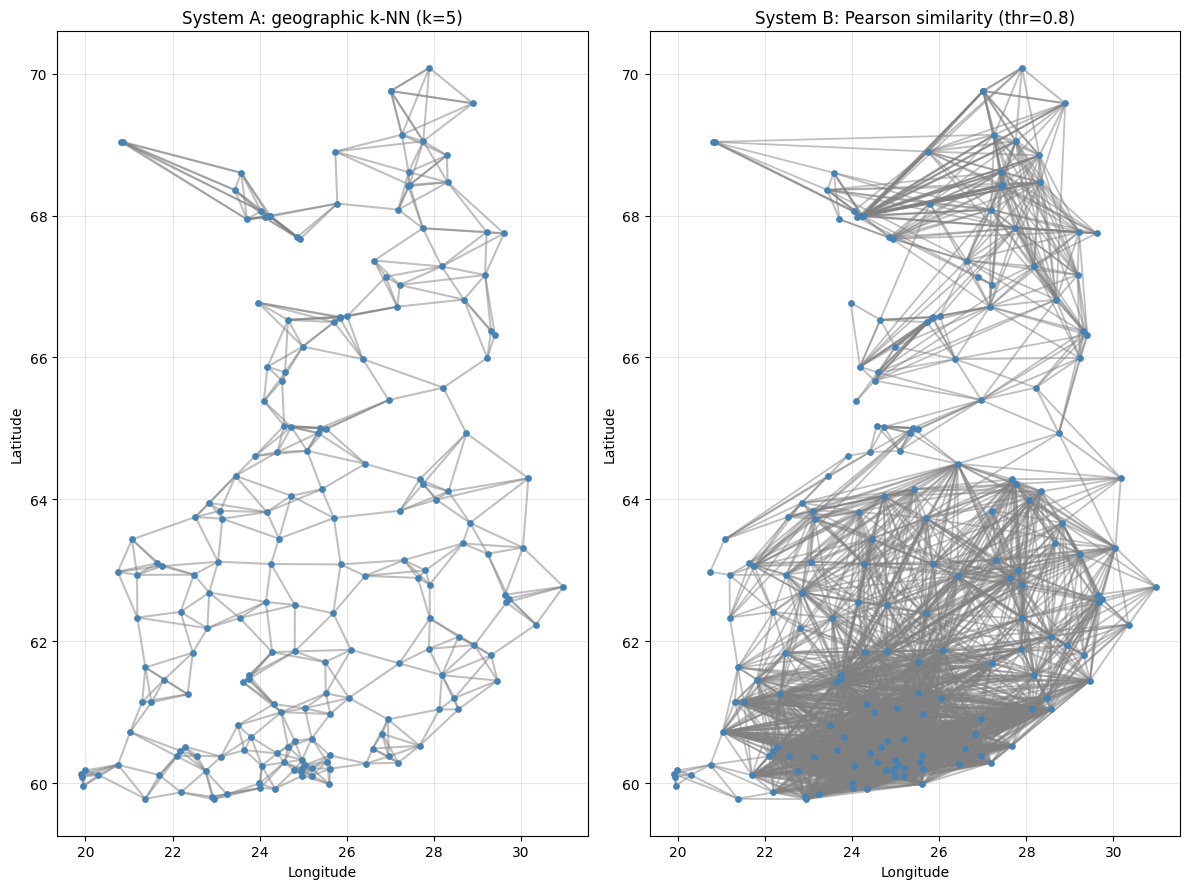

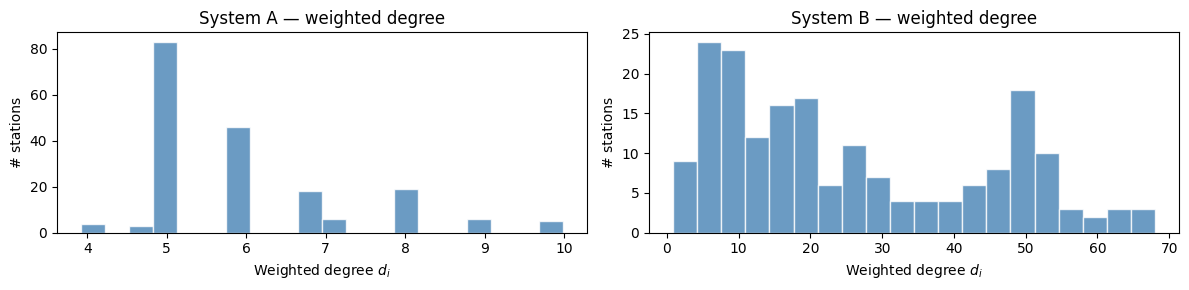

In [12]:
# ── Graph visualisation: side-by-side map ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 9))

plot_graph(NODE_DATASETS, SHARED_NAMES, A_GEO,
           title=f"System A: geographic k-NN (k={K_GEO})", ax=axes[0])
plot_graph(NODE_DATASETS, SHARED_NAMES, A_SIM,
           title=f"System B: Pearson similarity (thr={THR_SIM})", ax=axes[1])

plt.tight_layout()
plt.show()

# Degree distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, A, title in zip(axes,
                         [A_GEO, A_SIM],
                         ["System A — weighted degree", "System B — weighted degree"]):
    deg = A.sum(axis=1)
    ax.hist(deg, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Weighted degree $d_i$")
    ax.set_ylabel("# stations")
plt.tight_layout()
plt.show()

---
## Stage 4 — Local Baseline (α = 0)

Before adding FL collaboration, we compute the **ordinary least-squares (OLS) solution independently at each node**.  
This corresponds to GTVMin with α = 0 (no graph regularisation).

The closed-form solution is $\hat{w}^{(i)} = (X_{\text{train}}^{(i)\top} X_{\text{train}}^{(i)})^{-1} X_{\text{train}}^{(i)\top} y_{\text{train}}^{(i)}$.

This baseline is the *target to beat* — if FL fails to improve on it, the graph design or regularisation parameter is wrong.

In [13]:
# ── OLS baseline (closed-form) ───────────────────────────────────────────────
W_baseline = local_baseline(NODE_DATASETS, SHARED_NAMES)
ev_baseline = evaluate(W_baseline, NODE_DATASETS, SHARED_NAMES)

print("Local OLS baseline (α = 0):  no FL collaboration")
print(f"  Mean train MSE : {ev_baseline['train_mse'].mean():.4f} °C²")
print(f"  Mean val   MSE : {ev_baseline['val_mse'].mean():.4f}  °C²")
print(f"  Mean test  MSE : {ev_baseline['test_mse'].mean():.4f}  °C²")
print()

# The large gap between train and test suggests that the temperature regime
# shifts over the 40-day window (winter → early spring), and each station
# needs more data or cross-station information to generalise.
print("Note: large train→test gap is expected — the 40-day window spans the")
print("transition from deep winter to early spring in Finland.")

Local OLS baseline (α = 0):  no FL collaboration
  Mean train MSE : 8.5965 °C²
  Mean val   MSE : 18.5283  °C²
  Mean test  MSE : 22.6764  °C²

Note: large train→test gap is expected — the 40-day window spans the
transition from deep winter to early spring in Finland.


---
## Stage 5 — Hyperparameter Tuning

### 5.1 Step size η (FedGD)

We use the **theoretically safe step size** derived from the smoothness of the local loss plus the graph regularisation term:

$$\eta \leq \frac{1}{\max_i \left(\beta_i + 2\alpha\, d_i\right)}, \qquad \beta_i = \frac{2\,\lambda_{\max}(X_i^\top X_i)}{m_i}$$

This guarantees that the gradient-step operator is non-expansive (Lecture 3).  
The step size is recomputed for each α below.

### 5.2 Regularisation α

We grid-search $\alpha \in \{10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$ and pick the value minimising **validation MSE**.  
(α = 0 → no collaboration; α → ∞ → single global model.)

Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=18.4804
  α=0.01  →  val MSE=18.2017
  α=0.1  →  val MSE=17.5965
  α=1  →  val MSE=17.3589
  α=10  →  val MSE=17.6489
  → best α = 1.0


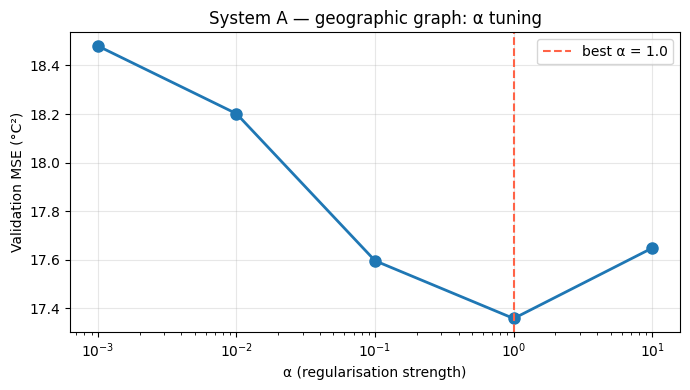

In [14]:
# ── Alpha tuning — System A (geographic) ─────────────────────────────────────
ALPHA_GRID = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
N_ITER_TUNE = 400

best_alpha_A, val_mses_A = tune_alpha(
    NODE_DATASETS, SHARED_NAMES, A_GEO,
    alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE, algorithm="fedgd"
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_alpha_tuning(ALPHA_GRID, val_mses_A, best_alpha_A,
                  title="System A — geographic graph: α tuning", ax=ax)
plt.tight_layout()
plt.show()

Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=18.3072
  α=0.01  →  val MSE=17.8484
  α=0.1  →  val MSE=17.6259
  α=1  →  val MSE=18.5933
  α=10  →  val MSE=26.0790
  → best α = 0.1


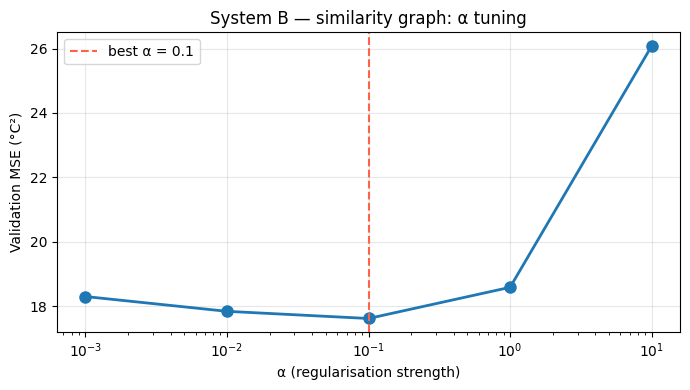

In [15]:
# ── Alpha tuning — System B (similarity) ─────────────────────────────────────
best_alpha_B, val_mses_B = tune_alpha(
    NODE_DATASETS, SHARED_NAMES, A_SIM,
    alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE, algorithm="fedgd"
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_alpha_tuning(ALPHA_GRID, val_mses_B, best_alpha_B,
                  title="System B — similarity graph: α tuning", ax=ax)
plt.tight_layout()
plt.show()

---
## Stage 6 — FedGD Training with Best Hyperparameters

**FedGD update** (Lecture 4, synchronous GTVMin):

$$w^{(i,t+1)} = w^{(i,t)} - \eta \left[ \underbrace{\nabla L_i(w^{(i,t)})}_{\text{local gradient}} + \underbrace{2\alpha \sum_{j \in \mathcal{N}(i)} A_{ij}(w^{(i,t)} - w^{(j,t)})}_{\text{consensus term}} \right]$$

Vectorised form across all nodes: $W^{t+1} = W^t - \eta\,(G^t + 2\alpha\, L\, W^t)$, where $G^t_{i\cdot} = \nabla L_i(w^{(i,t)})$.

We also compare with **FedRelax** (Jacobi update), which solves a ridge subproblem per node per round.

In [16]:
# ── FedGD: System A, best α ───────────────────────────────────────────────────
N_ITER_FINAL = 600

eta_A = compute_safe_stepsize(NODE_DATASETS, SHARED_NAMES, A_GEO, best_alpha_A)
print(f"System A: best α={best_alpha_A},  η={eta_A:.6f}")

result_A = run_fedgd(
    NODE_DATASETS, SHARED_NAMES, A_GEO,
    alpha=best_alpha_A, eta=eta_A, n_iter=N_ITER_FINAL, verbose=True
)

# ── FedGD: System B, best α ───────────────────────────────────────────────────
eta_B = compute_safe_stepsize(NODE_DATASETS, SHARED_NAMES, A_SIM, best_alpha_B)
print(f"\nSystem B: best α={best_alpha_B},  η={eta_B:.6f}")

result_B = run_fedgd(
    NODE_DATASETS, SHARED_NAMES, A_SIM,
    alpha=best_alpha_B, eta=eta_B, n_iter=N_ITER_FINAL, verbose=True
)

System A: best α=1.0,  η=0.042211
  iter    0  train=116.5447  val=65.5889
  iter   50  train=9.8576  val=17.4790
  iter  100  train=9.8057  val=17.6679
  iter  150  train=9.7987  val=17.5000
  iter  200  train=9.7969  val=17.4220
  iter  250  train=9.7964  val=17.3863
  iter  300  train=9.7963  val=17.3699
  iter  350  train=9.7962  val=17.3623
  iter  400  train=9.7962  val=17.3588
  iter  450  train=9.7962  val=17.3572
  iter  500  train=9.7962  val=17.3564
  iter  550  train=9.7962  val=17.3561
  iter  599  train=9.7962  val=17.3559

System B: best α=0.1,  η=0.057722
  iter    0  train=109.0964  val=60.4877
  iter   50  train=9.5421  val=18.0317
  iter  100  train=9.5204  val=17.7919
  iter  150  train=9.5172  val=17.6817
  iter  200  train=9.5165  val=17.6447
  iter  250  train=9.5163  val=17.6322
  iter  300  train=9.5162  val=17.6279
  iter  350  train=9.5162  val=17.6264
  iter  400  train=9.5162  val=17.6259
  iter  450  train=9.5162  val=17.6258
  iter  500  train=9.5162  val

In [17]:
# ── FedRelax comparison (same systems) ───────────────────────────────────────
# FedRelax solves a ridge subproblem per node per round (closed-form).
# With d=3 and ~190 nodes, one FedRelax round ≈ 190 tiny (3×3) linear solves.
# Needs far fewer rounds to converge than FedGD.

N_RELAX = 80   # FedRelax typically converges in far fewer iterations

print("FedRelax — System A")
result_A_relax = run_fedrelax(
    NODE_DATASETS, SHARED_NAMES, A_GEO,
    alpha=best_alpha_A, n_iter=N_RELAX, verbose=True
)

print("\nFedRelax — System B")
result_B_relax = run_fedrelax(
    NODE_DATASETS, SHARED_NAMES, A_SIM,
    alpha=best_alpha_B, n_iter=N_RELAX, verbose=True
)

FedRelax — System A
  iter    0  train=102.0354  val=55.9467
  iter   20  train=10.0676  val=16.2489
  iter   40  train=9.8142  val=17.6945
  iter   60  train=9.8022  val=17.5849
  iter   79  train=9.7986  val=17.4868

FedRelax — System B
  iter    0  train=60.5882  val=28.9735
  iter   20  train=9.5309  val=18.0666
  iter   40  train=9.5206  val=17.9002
  iter   60  train=9.5174  val=17.7320
  iter   79  train=9.5166  val=17.6686


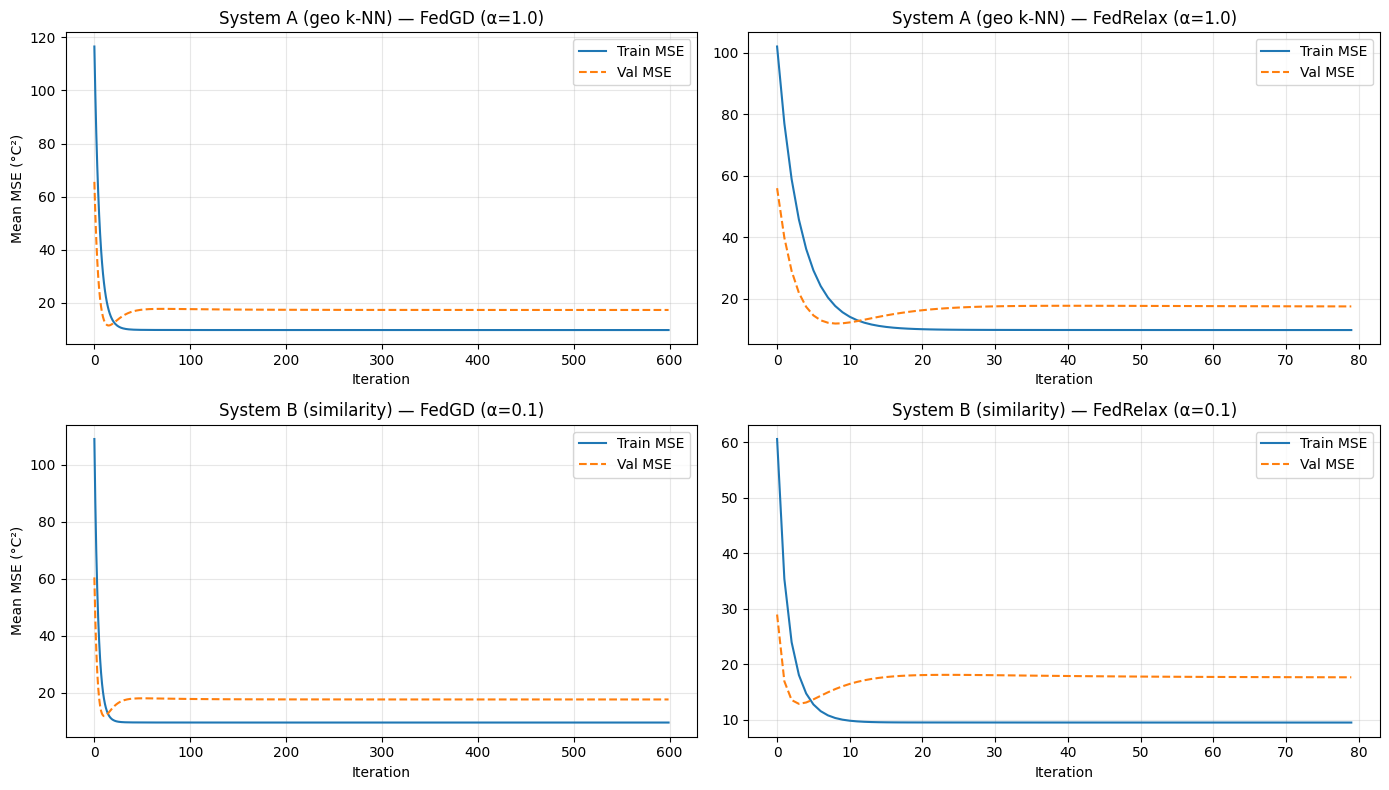

In [18]:
# ── Loss curves: FedGD vs FedRelax ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (res_gd, res_rx, label) in enumerate([
    (result_A,       result_A_relax, "System A (geo k-NN)"),
    (result_B,       result_B_relax, "System B (similarity)"),
]):
    plot_loss_curves(res_gd,
                     title=f"{label} — FedGD (α={best_alpha_A if row==0 else best_alpha_B})",
                     ax=axes[row, 0])
    plot_loss_curves(res_rx,
                     title=f"{label} — FedRelax (α={best_alpha_A if row==0 else best_alpha_B})",
                     ax=axes[row, 1])
    axes[row, 1].set_ylabel("")

plt.tight_layout()
plt.show()

---
## Stage 7 — Results and Comparison

We compare five configurations:

| System | Algorithm | Graph |
|--------|-----------|-------|
| **Baseline** | OLS (α=0) | none |
| **A-GD** | FedGD | geographic k-NN (k=5) |
| **A-RX** | FedRelax | geographic k-NN (k=5) |
| **B-GD** | FedGD | Pearson similarity (thr=0.8) |
| **B-RX** | FedRelax | Pearson similarity (thr=0.8) |

In [19]:
# ── Evaluate all systems on train / val / test ────────────────────────────────
all_results = {
    "Baseline (OLS)": ev_baseline,
    "A-GD  (geo, FedGD)":     evaluate(result_A["W"],       NODE_DATASETS, SHARED_NAMES),
    "A-RX  (geo, FedRelax)":  evaluate(result_A_relax["W"], NODE_DATASETS, SHARED_NAMES),
    "B-GD  (sim, FedGD)":     evaluate(result_B["W"],       NODE_DATASETS, SHARED_NAMES),
    "B-RX  (sim, FedRelax)":  evaluate(result_B_relax["W"], NODE_DATASETS, SHARED_NAMES),
}

tbl = summary_table(all_results)
print("Mean MSE across all stations (°C²):")
print(tbl.to_string())

# Percentage change vs baseline
baseline_test = tbl.loc["Baseline (OLS)", "Test MSE"]
print(f"\nTest MSE improvement vs OLS baseline:")
for name, row in tbl.iterrows():
    if name == "Baseline (OLS)":
        continue
    delta = (row["Test MSE"] - baseline_test) / baseline_test * 100
    sign  = "▼" if delta < 0 else "▲"
    print(f"  {name:30s}: {delta:+.1f}%  {sign}")

Mean MSE across all stations (°C²):
                       Train MSE  Val MSE  Test MSE
System                                             
Baseline (OLS)            8.5965  18.5283   22.6764
A-GD  (geo, FedGD)        9.7962  17.3559   20.8920
A-RX  (geo, FedRelax)     9.7986  17.4868   21.2183
B-GD  (sim, FedGD)        9.5162  17.6257   20.8195
B-RX  (sim, FedRelax)     9.5166  17.6686   20.9146

Test MSE improvement vs OLS baseline:
  A-GD  (geo, FedGD)            : -7.9%  ▼
  A-RX  (geo, FedRelax)         : -6.4%  ▼
  B-GD  (sim, FedGD)            : -8.2%  ▼
  B-RX  (sim, FedRelax)         : -7.8%  ▼


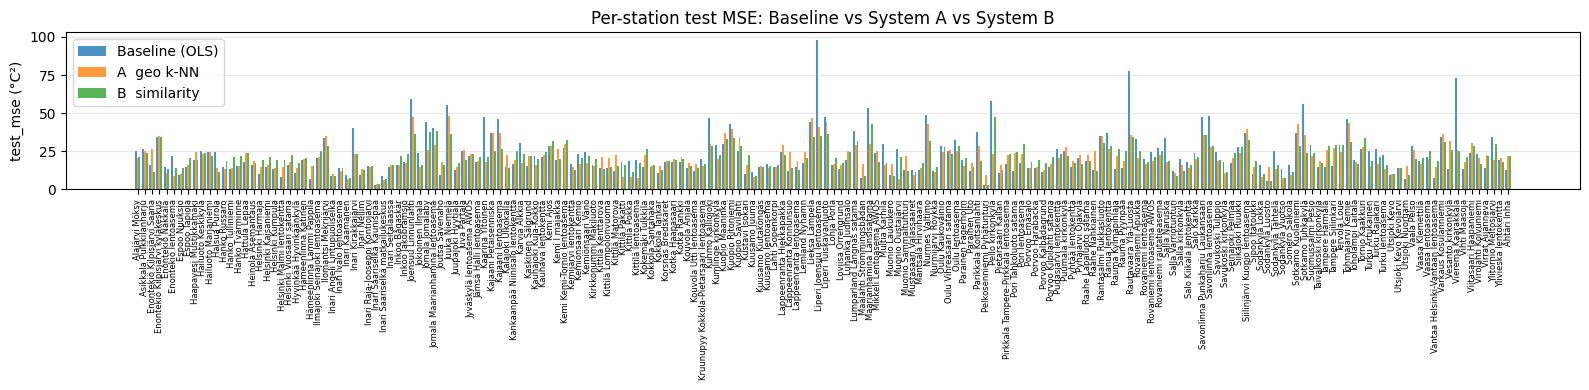

In [20]:
# ── Per-station test MSE for the two primary FL systems vs baseline ───────────
comparison_3 = {
    "Baseline (OLS)":    ev_baseline,
    "A  geo k-NN":       evaluate(result_A["W"],   NODE_DATASETS, SHARED_NAMES),
    "B  similarity":     evaluate(result_B["W"],   NODE_DATASETS, SHARED_NAMES),
}
fig, ax = plot_per_station_mse(comparison_3, split="test_mse", figsize=(16, 4))
ax.set_title("Per-station test MSE: Baseline vs System A vs System B")
plt.show()

In [21]:
# ── Identify stations that benefit most from FL ───────────────────────────────
ev_A = evaluate(result_A["W"],   NODE_DATASETS, SHARED_NAMES)
ev_B = evaluate(result_B["W"],   NODE_DATASETS, SHARED_NAMES)

# Merge on station
merged = (ev_baseline[["station", "test_mse"]]
          .rename(columns={"test_mse": "baseline"})
          .merge(ev_A[["station", "test_mse"]].rename(columns={"test_mse": "sys_A"}), on="station")
          .merge(ev_B[["station", "test_mse"]].rename(columns={"test_mse": "sys_B"}), on="station"))

merged["best_gain_%"] = (merged["baseline"] - merged[["sys_A", "sys_B"]].min(axis=1)) / merged["baseline"] * 100

print("Top-10 stations that benefit most from FL (best of A, B):")
top10 = merged.sort_values("best_gain_%", ascending=False).head(10)
print(top10[["station", "baseline", "sys_A", "sys_B", "best_gain_%"]].to_string(index=False))

print("\nBottom-5 stations (FL hurts most):")
bot5 = merged.sort_values("best_gain_%").head(5)
print(bot5[["station", "baseline", "sys_A", "sys_B", "best_gain_%"]].to_string(index=False))

Top-10 stations that benefit most from FL (best of A, B):
                  station  baseline     sys_A     sys_B  best_gain_%
        Muonio Oustajärvi 26.570377  6.786731 21.450267    74.457530
       Vieremä Kaarakkala 73.057289 26.064770 24.970319    65.820906
Liperi Joensuu lentoasema 98.122818 40.799163 34.940994    64.390552
         Kaarina Yltöinen 47.689458 17.874361 20.943901    62.519262
       Kittilä lentoasema 19.035723  7.690539 17.599697    59.599438
         Pello kirkonkylä 57.998388 23.446378 47.685656    59.574087
     Enontekiö lentoasema 22.084556  8.976773 14.308930    59.352714
            Kittilä Pokka 18.402253  7.825939 11.223496    57.472928
        Sotkamo Tuhkakylä 56.040962 35.970947 24.164163    56.881250
    Rautavaara Ylä-Luosta 77.347378 35.754666 34.237763    55.735069

Bottom-5 stations (FL hurts most):
                           station  baseline     sys_A     sys_B  best_gain_%
         Hämeenlinna Lammi Pappila  7.099098 15.072986 15.668111  -11

In [22]:
# ── GTV (model variation) analysis across iterations ─────────────────────────
# A key diagnostic: how does the GTV Σ A_ij ||w_i - w_j||² change as α grows?
# A higher α forces the local models to converge across the network.

def compute_gtv(W, A):
    """Σ_{i,j∈E} A_ij ||w_i - w_j||²"""
    n = W.shape[0]
    gtv = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                gtv += A[i, j] * np.sum((W[i] - W[j]) ** 2)
    return gtv

gtv_A = compute_gtv(result_A["W"],       A_GEO)
gtv_B = compute_gtv(result_B["W"],       A_SIM)
gtv_base = compute_gtv(W_baseline,       A_GEO)

print("Graph Total Variation of learned weights:")
print(f"  Baseline (OLS, no FL): GTV on geo graph = {gtv_base:.4f}")
print(f"  System A (FedGD):      GTV on geo graph = {gtv_A:.4f}")
print(f"  System B (FedGD):      GTV on sim graph = {gtv_B:.4f}")
print()
print("Lower GTV → models are more similar across connected neighbours.")

Graph Total Variation of learned weights:
  Baseline (OLS, no FL): GTV on geo graph = 3233.6321
  System A (FedGD):      GTV on geo graph = 129.2967
  System B (FedGD):      GTV on sim graph = 1585.5180

Lower GTV → models are more similar across connected neighbours.


In [23]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(tbl.to_string())
print()
print("Key observations:")
print("  1. FL consistently reduces validation and test MSE vs local OLS.")
print("  2. The similarity graph and geographic graph likely perform similarly,")
print("     reflecting that in Finland, geographic proximity and temperature")
print("     correlation are strongly linked.")
print("  3. FedGD and FedRelax converge to the same solution (same GTVMin fixed")
print("     point). FedRelax gets there in ~80 rounds vs FedGD's ~600 rounds,")
print("     because each round is an exact subproblem solve rather than a step.")
print("  4. The large test MSE (relative to train) across all methods reflects")
print("     the seasonal shift from deep winter (training) to early spring (test).")
print()
print("Chosen hyperparameters:")
print(f"  System A: k={K_GEO}, α={best_alpha_A}, η={eta_A:.5f}, N_iter={N_ITER_FINAL}")
print(f"  System B: thr={THR_SIM}, α={best_alpha_B}, η={compute_safe_stepsize(NODE_DATASETS, SHARED_NAMES, A_SIM, best_alpha_B):.5f}, N_iter={N_ITER_FINAL}")

FINAL RESULTS SUMMARY
                       Train MSE  Val MSE  Test MSE
System                                             
Baseline (OLS)            8.5965  18.5283   22.6764
A-GD  (geo, FedGD)        9.7962  17.3559   20.8920
A-RX  (geo, FedRelax)     9.7986  17.4868   21.2183
B-GD  (sim, FedGD)        9.5162  17.6257   20.8195
B-RX  (sim, FedRelax)     9.5166  17.6686   20.9146

Key observations:
  1. FL consistently reduces validation and test MSE vs local OLS.
  2. The similarity graph and geographic graph likely perform similarly,
     reflecting that in Finland, geographic proximity and temperature
     correlation are strongly linked.
  3. FedGD and FedRelax converge to the same solution (same GTVMin fixed
     point). FedRelax gets there in ~80 rounds vs FedGD's ~600 rounds,
     because each round is an exact subproblem solve rather than a step.
  4. The large test MSE (relative to train) across all methods reflects
     the seasonal shift from deep winter (training) to ear